16
Family count :  0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: FamilyCount, Length: 891, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  HasCabin     891 non-null    bool   
 13  HasFamily    891 non-null    int64  
 14  FamilyCount  891 non-null    int64  
 15  Honorifics   

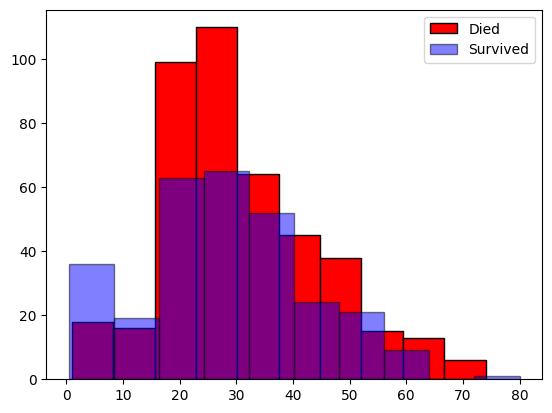

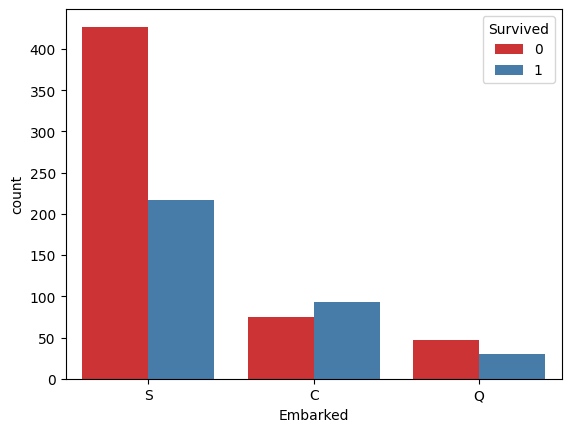

############################################################
Family count survival rate : 


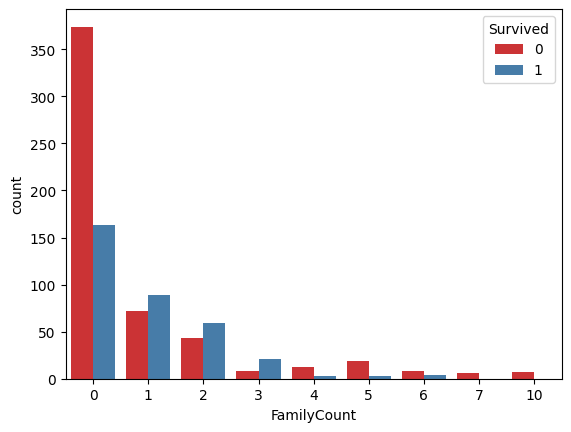

############################################################


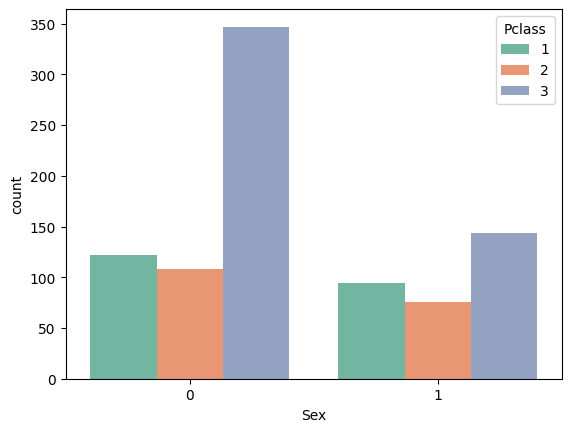

############################################################


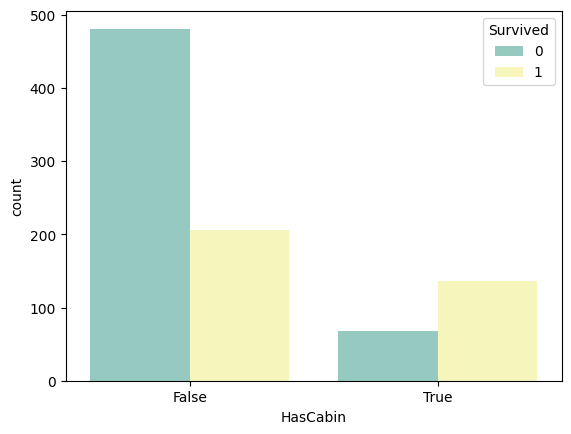

############################################################


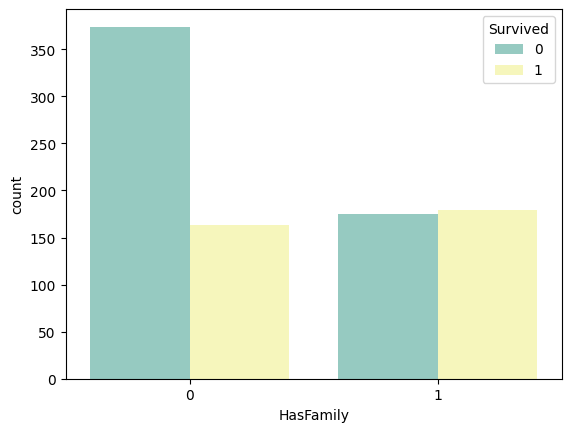

############################################################


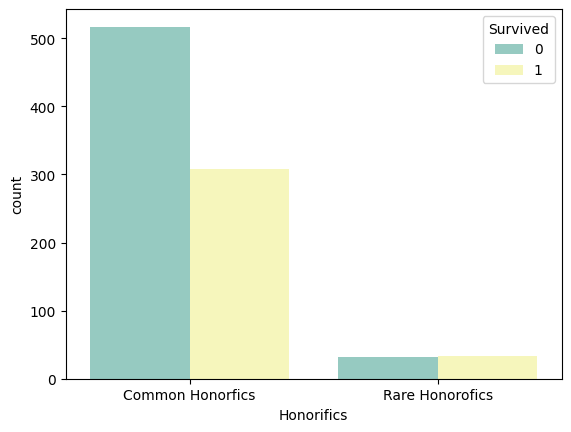

############################################################
SUrvival rate of adult man vs young boys :
############################################################
       PassengerId    Survived      Pclass         Sex         Age  \
count   891.000000  891.000000  891.000000  891.000000  714.000000   
mean    446.000000    0.383838    2.308642    0.352413   29.699118   
std     257.353842    0.486592    0.836071    0.477990   14.526497   
min       1.000000    0.000000    1.000000    0.000000    0.420000   
25%     223.500000    0.000000    2.000000    0.000000   20.125000   
50%     446.000000    0.000000    3.000000    0.000000   28.000000   
75%     668.500000    1.000000    3.000000    1.000000   38.000000   
max     891.000000    1.000000    3.000000    1.000000   80.000000   

            SibSp       Parch        Fare   HasFamily  FamilyCount  
count  891.000000  891.000000  891.000000  891.000000   891.000000  
mean     0.523008    0.381594   32.204208    0.397306     0.904602

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path().cwd()
DATA_PATH = BASE_DIR.parent / "data" / "train.csv"
nominal_encoder = OneHotEncoder()
data = pd.read_csv(DATA_PATH)
data["Sex"] = (data["Sex"] == "female").astype(int)
data['HasCabin'] = data["Cabin"].notna()
data["HasFamily"] = ((data["Parch"] > 0) | (data["SibSp"] > 0)).astype(int)
data["FamilyCount"] = data["Parch"]+ data["SibSp"] 
data["Honorifics"] = data["Name"].str.extract(",\s*(\w+)\.")
data.columns = data.columns.str.strip()

print("="*60)

print(data["Honorifics"].nunique())
print("="*60)
print("Family count : " ,data["FamilyCount"])
print("="*60)

# data["Embarked"]= nominal_encoder.fit_transform(data["Embarked"])
print(data.info(memory_usage="deep"))
print("="*60)
print(data.groupby("Sex")["Survived"].mean())
print("-"* 100)
print(data.groupby("HasCabin")["Survived"].mean())
print("-"* 100)
# print(data.groupby("Pclass")["Survived"].mean())
print("-"* 100)

print(f'Survival rate of Female based on Pclass: {data[data["Sex"] == 1].groupby("Pclass")["Survived"].mean()}')




data["Name"].str.split()
data["Honorifics"] = np.where(data["Honorifics"].str.contains("Mrs|Miss|Mr" ) , "Common Honorfics" ,  "Rare Honorofics" )
plt.hist(data[data["Survived"] == 0]["Age"]   ,  color="red" , edgecolor='black' , label="Died")
plt.hist(data[data["Survived"] == 1]["Age"]  , alpha=0.5 , color="blue" , edgecolor='black' , label="Survived")
plt.legend(loc='upper right')

plt.show()



sns.countplot(data=data, x="Embarked", hue="Survived", palette="Set1")
plt.show()
print("#"*60)
print("Family count survival rate : ")

sns.countplot(data=data, x="FamilyCount", hue="Survived", palette="Set1")
plt.show()
print("#"*60)
sns.countplot(data=data , x="Sex" , hue="Pclass" , palette="Set2")
plt.show()

print("#"*60)

sns.countplot(data=data , x="HasCabin" , hue="Survived" , palette="Set3")
plt.show()
print("#"*60)


sns.countplot(data=data , x="HasFamily" , hue="Survived" , palette="Set3")
plt.show()
print("#"*60)

sns.countplot(data=data , x="Honorifics" , hue="Survived" , palette="Set3")
plt.show()

print("#"*60)

print("SUrvival rate of adult man vs young boys :")
data.groupby("Honorifics")["Survived"].mean()
print("#"*60)



# sns.countplot(data=data , x="Honorfics" , hue="Survived" , palette="Set3")
# plt.show()
# print("#"*60)

print(data.describe())
y = data["Survived"]
X = data.drop(columns=["Survived"])
X["Age"] = X["Age"].fillna(X["Age"].median())
# print(X)
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])
# X.isna().sum()


# plt.scatter(X["Age"], X["SibSp"])

# plt.scatter(X["Parch"] , y)

# X["SibSp"].plot.kde()
# X["Parch"].plot.kde()
# X["Pclass"].plot.kde()


Selected_cols = ["Embarked" , "Age" , "FamilyCount" , "HasCabin" , "Honorifics" , "Sex" , "Pclass"]
Selected_Data = data[Selected_cols].copy()

# Selected_Data = pd.get_dummies(Selected_Data , columns=["Embarked"] , drop_first= True)

